# MediFirst — Fine-Tuning (Notebook 2 of 2)

**Model:** Google Gemma 3 1B IT  |  **Method:** QLoRA (4-bit NF4 + LoRA)  
**Dataset:** Upload `mediFirst_dataset.json` from Notebook 1  
**Platform:** Google Colab Free Tier (T4 GPU)

### Estimated Runtimes

| Phase | Time |
|---|---|
| Upload + preprocessing | ~3-5 min |
| Model loading + LoRA setup | ~3-5 min |
| Training (3 epochs, packing) | ~2-3 hours |
| Evaluation | ~5 min |
| **Total** | **~2.5-3.5 hours** |

> **[!IMPORTANT]**  
> Set your runtime to **T4 GPU** before running: **Runtime** → **Change runtime type** → **T4 GPU**

---

## Section 1 — Setup & Installation

In [5]:
# 1a. Install dependencies (compatible with Colab + official Gemma guide)
!pip install -q \
    torch \
    transformers \
    peft \
    trl \
    bitsandbytes \
    accelerate \
    datasets \
    huggingface_hub \
    sentencepiece \
    protobuf \
    matplotlib \
    pandas \
    tqdm

print("[SUCCESS] All packages installed.")

[SUCCESS] All packages installed.


In [6]:
# 1b. Create project directories
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Avoid fork warnings
BASE_DIR = "/content/MediFirst"
DIRS = [
    BASE_DIR,
    f"{BASE_DIR}/checkpoints",
    f"{BASE_DIR}/dataset_splits",
    f"{BASE_DIR}/medifirst-lora-adapter",
]

for d in DIRS:
    os.makedirs(d, exist_ok=True)

print("[SUCCESS] Project directories created.")

[SUCCESS] Project directories created.


In [7]:
# 1c. Hugging Face Token (PASTE YOUR TOKEN HERE)
HF_TOKEN = "<YOUR_HF_TOKEN>"
assert HF_TOKEN, "[ERROR] Set HF_TOKEN above before running!"

from huggingface_hub import login

login(token=HF_TOKEN)
print("[SUCCESS] Logged in to Hugging Face Hub.")

[SUCCESS] Logged in to Hugging Face Hub.


In [8]:
# 1d. GPU & RAM diagnostics
!nvidia-smi
print()
!cat /proc/meminfo | grep MemAvailable

import torch

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1e9
    print(f"\n[SYSTEM] GPU: {props.name}")
    print(f"[SYSTEM] Total VRAM: {vram_gb:.2f} GB")
    if vram_gb < 14:
        print("[WARNING] Low VRAM detected. Training may be slow.")
else:
    print("[ERROR] No GPU detected! Go to Runtime -> Change runtime type -> T4 GPU")

Sun Apr  5 08:41:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# 1e. Global speed settings & memory cleanup
import torch
import gc

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

print("[SUCCESS] TF32 & cuDNN benchmark enabled.")

gc.collect()
torch.cuda.empty_cache()

[SUCCESS] TF32 & cuDNN benchmark enabled.


## Section 2 — Upload & Prepare DatasetUpload the `mediFirst_dataset.json` file generated from Notebook 1.

In [10]:
# 2a. Upload dataset file
import os

FINAL_DATASET = "/content/MediFirst/mediFirst_dataset.json"

if os.path.exists(FINAL_DATASET):
    print("[SUCCESS] Dataset already present — skipping upload.")
else:
    from google.colab import files
    print("[ACTION] Upload mediFirst_dataset.json from Notebook 1:")
    uploaded = files.upload()
    # Move uploaded file to project directory
    for filename in uploaded:
        os.rename(filename, FINAL_DATASET)
        print(f"[SUCCESS] Moved {filename} → {FINAL_DATASET}")

[ACTION] Upload mediFirst_dataset.json from Notebook 1:


Saving mediFirst_dataset.json to mediFirst_dataset.json
[SUCCESS] Moved mediFirst_dataset.json → /content/MediFirst/mediFirst_dataset.json


In [11]:
# 2b. Load dataset & apply prompt template
import json
from datasets import Dataset

FINAL_DATASET = "/content/MediFirst/mediFirst_dataset.json"

with open(FINAL_DATASET) as f:
    raw_data = json.load(f)

print(f"[SUCCESS] Loaded {len(raw_data)} examples.")

def format_example(ex):
    text = (
        f"Below is a medical question or emergency scenario.\n"
        f"Provide a clear, structured, and actionable medical response.\n\n"
        f"### Instruction:\n{ex['instruction']}\n\n"
        f"### Input:\n{ex.get('input', '')}\n\n"
        f"### Response:\n{ex['output']}"
    )
    return {"text": text, "category": ex.get("category", "unknown")}

formatted = [format_example(ex) for ex in raw_data]
dataset = Dataset.from_list(formatted)

print(f"[SUCCESS] Dataset created: {dataset}")
print("\n--- Sample formatted prompt ---")
print(dataset[0]["text"][:600])

[SUCCESS] Loaded 2899 examples.
[SUCCESS] Dataset created: Dataset({
    features: ['text', 'category'],
    num_rows: 2899
})

--- Sample formatted prompt ---
Below is a medical question or emergency scenario.
Provide a clear, structured, and actionable medical response.

### Instruction:
A 45-year-old colleague suddenly collapses, is unresponsive, and is not breathing. You are alone. How do you perform CPR?

### Input:


### Response:
**Assessment:** The victim is unconscious and shows signs of cardiac arrest (no breathing or only gasping). Immediate intervention is required to maintain perfusion.

**Immediate Steps:**
1. Check the scene for safety, then tap the victim's shoulder and shout to confirm unresponsiveness.
2. Call emergency services (91


In [12]:
# 2c. Tokenize (fast, batched, multi-proc)
from transformers import AutoTokenizer

MODEL_ID = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, token=HF_TOKEN)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"
MAX_LENGTH = 512

def tokenize_fn(batch):
    tokens = tokenizer(
        batch["text"], max_length=MAX_LENGTH, truncation=True, padding=False
    )
    tokens["num_tokens"] = [len(ids) for ids in tokens["input_ids"]]
    return tokens

print("[PROCESS] Tokenizing (batched, num_proc=2)...")
dataset = dataset.map(
    tokenize_fn, batched=True, batch_size=1000, num_proc=2, desc="Tokenizing"
)

before = len(dataset)
dataset = dataset.filter(lambda x: x["num_tokens"] <= MAX_LENGTH)
after = len(dataset)

print(f"   Filtered: {before - after} examples exceeded {MAX_LENGTH} tokens.")
print(f"[SUCCESS] Final tokenized dataset: {after} examples")

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

[PROCESS] Tokenizing (batched, num_proc=2)...


Tokenizing (num_proc=2):   0%|          | 0/2899 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2899 [00:00<?, ? examples/s]

   Filtered: 0 examples exceeded 512 tokens.
[SUCCESS] Final tokenized dataset: 2899 examples


In [13]:
# 2d. Train / Val / Test split
import os
from datasets import DatasetDict, load_from_disk

SPLIT_DIR = "/content/MediFirst/dataset_splits"

if os.path.exists(f"{SPLIT_DIR}/train"):
    splits = DatasetDict({
        "train": load_from_disk(f"{SPLIT_DIR}/train"),
        "validation": load_from_disk(f"{SPLIT_DIR}/validation"),
        "test": load_from_disk(f"{SPLIT_DIR}/test"),
    })
    print("[SUCCESS] Loaded existing splits.")
else:
    ds_clean = dataset.remove_columns(["input_ids", "attention_mask", "num_tokens"])
    split1 = ds_clean.train_test_split(test_size=0.2, seed=42)
    split2 = split1["test"].train_test_split(test_size=0.5, seed=42)

    splits = DatasetDict({
        "train": split1["train"],
        "validation": split2["train"],
        "test": split2["test"],
    })

    for name in splits:
        splits[name].save_to_disk(f"{SPLIT_DIR}/{name}")
    print("[SAVE] Splits saved.")

for name, ds in splits.items():
    print(f"   {name:>12}: {len(ds)} examples")

Saving the dataset (0/1 shards):   0%|          | 0/2319 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/290 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/290 [00:00<?, ? examples/s]

[SAVE] Splits saved.
          train: 2319 examples
     validation: 290 examples
           test: 290 examples


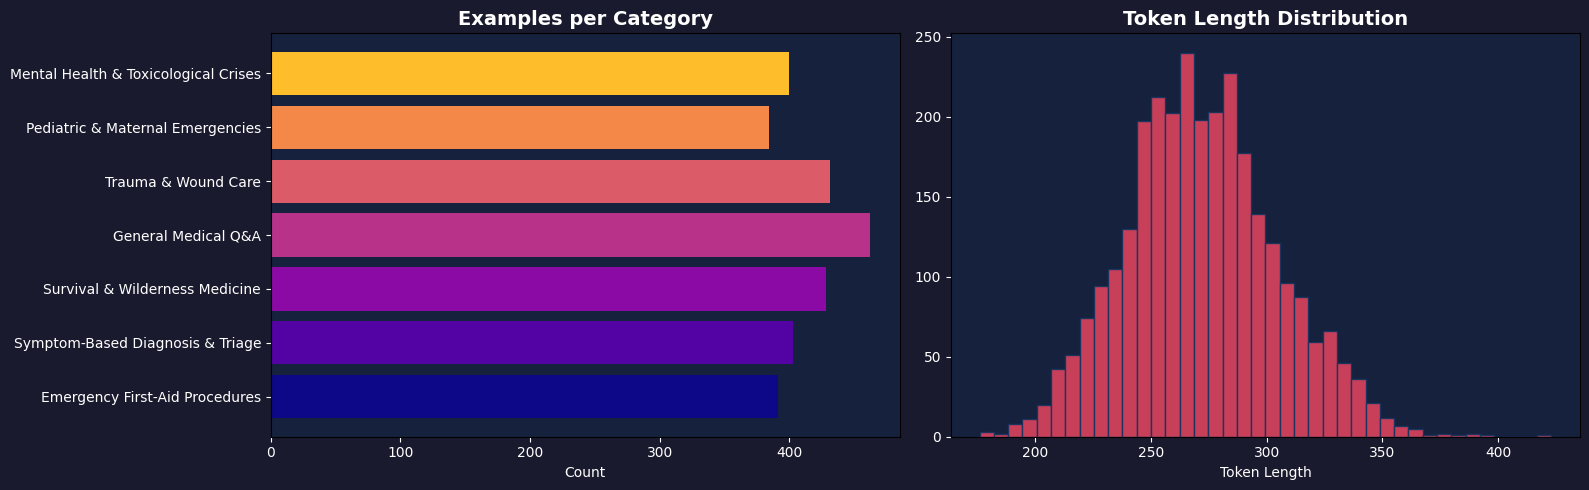

In [14]:
# 2e. Dataset visualization
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter

matplotlib.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor": "#16213e",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
})

cats = [ex["category"] for ex in raw_data]
cat_counts = Counter(cats)
token_lens = dataset["num_tokens"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
names = list(cat_counts.keys())
counts = list(cat_counts.values())
colors = plt.cm.plasma([i / len(names) for i in range(len(names))])

axes[0].barh(names, counts, color=colors)
axes[0].set_xlabel("Count")
axes[0].set_title("Examples per Category", fontsize=14, fontweight="bold")

axes[1].hist(token_lens, bins=40, color="#e94560", edgecolor="#0f3460", alpha=0.85)
axes[1].set_xlabel("Token Length")
axes[1].set_title("Token Length Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("/content/MediFirst/dataset_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

import gc, torch
gc.collect()
torch.cuda.empty_cache()

---## Section 3 — Model LoadingLoad **Gemma 3 1B IT** in 4-bit quantization (NF4 + double quantization).

In [15]:
# 3a. Load base model in 4-bit
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = "google/gemma-3-1b-it"

# Check GPU capability for dtype selection
if torch.cuda.get_device_capability()[0] >= 8:
    compute_dtype = torch.bfloat16
else:
    compute_dtype = torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

print("[PROCESS] Loading model (takes 2-3 minutes)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype,
    low_cpu_mem_usage=True,
    token=HF_TOKEN,
)

# Reload tokenizer tied to model (ensures consistency)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model.config.use_cache = False
model.enable_input_require_grads()

print("[SUCCESS] Model loaded!")
print(f"   Compute dtype: {compute_dtype}")
print(f"   GPU memory used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

[PROCESS] Loading model (takes 2-3 minutes)...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

[SUCCESS] Model loaded!
   Compute dtype: torch.float16
   GPU memory used: 0.97 GB


---## Section 4 — LoRA Configuration

In [16]:
# 4a. Apply LoRA adapters
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    inference_mode=False,
)

model = get_peft_model(model, lora_config)
model.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": False}
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"[SUCCESS] LoRA applied!")
print(f"   Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

[SUCCESS] LoRA applied!
   Trainable params: 1,490,944 / 652,496,000 (0.23%)


---## Section 5 — Baseline Responses (Before Training)> **[!WARNING]** These are captured BEFORE training to compare with fine-tuned responses later.

In [18]:
# 5a. Generate base model responses
import json
import os
import torch

BASE_RESPONSES_PATH = "/content/MediFirst/base_model_responses.json"
EVAL_PROMPTS = [
    "A person has collapsed and is not breathing. They have no pulse. Describe the CPR procedure step by step.",
    "Someone has severe burns on their forearm from boiling water. What should I do immediately?",
    "A hiker complains of severe chest pain, shortness of breath, and dizziness at 12,000 feet altitude. How should I assess and respond?",
    "A patient presents with sudden severe headache, stiff neck, and sensitivity to light. What could this be and what should I do?",
    "I was bitten by a snake in the wilderness. The bite area is swelling and turning purple. What are the immediate steps?",
    "How do you purify water in a survival situation when you have no commercial filters?",
    "A 2-year-old is choking on a small toy and cannot cry or cough. What is the correct first aid procedure?",
    "A pregnant woman at 38 weeks is having contractions every 3 minutes and the baby is crowning. How do I assist with emergency delivery?",
    "Someone has taken a large number of unknown pills and is becoming drowsy and confused. What should I do?",
    "A person is having a severe panic attack - hyperventilating, chest pain, feeling of impending doom. How do I help them?",
]

if os.path.exists(BASE_RESPONSES_PATH):
    with open(BASE_RESPONSES_PATH) as f:
        base_responses = json.load(f)
    print(f"[SUCCESS] Loaded {len(base_responses)} cached base model responses.")
else:
    print("[PROCESS] Generating base model responses...")
    model.eval()
    base_responses = []
    with torch.inference_mode():
        for i, pt in enumerate(EVAL_PROMPTS):
            messages = [{"role": "user", "content": pt}]
            prompt = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            inputs = tokenizer(
                prompt, return_tensors="pt", add_special_tokens=False
            ).to(model.device)
            outputs = model.generate(
                **inputs, max_new_tokens=300, do_sample=False, use_cache=True
            )
            response = tokenizer.decode(
                outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
            ).strip()
            base_responses.append({"prompt": pt, "response": response})
            print(f"   [{i+1}/{len(EVAL_PROMPTS)}] Done")
            print(response)

    with open(BASE_RESPONSES_PATH, 'w') as f:
        json.dump(base_responses, f, indent=2)
    print("[SAVE] Base responses saved.")

    # Switch back to training mode
    model.train()
    model.config.use_cache = False

import gc
gc.collect()
torch.cuda.empty_cache()

[PROCESS] Generating base model responses...
   [1/10] Done
Okay, this is a critical situation. **Right now, your priority is to call emergency services immediately (911 or your local emergency number) and begin CPR immediately.**  Don't hesitate – every second counts.  Here's a breakdown of the CPR procedure, emphasizing the steps and what you're aiming for. **This is a simplified guide and should not replace formal training.  It's highly recommended that you take a certified CPR course.**

**1. Assess the Situation & Ensure Safety (Seconds)**

* **Check for Responsiveness:** Gently tap the person's shoulder and shout, "Are you okay? Can you hear me?"
* **Check for Breathing:** Look, listen, and feel for breathing for no more than 10 seconds.  Look for chest rise and fall.  Feel for air on your cheek.  If they aren'*t breathing normally, or only gasping, assume they don't have a pulse.
* **Call for Help Immediately:**  Yell for help – "Help!  Someone is not breathing!"  If you're alon

---## Section 6 — Fine-TuningTrain with **SFTTrainer** using TRL's `SFTConfig` (packing enabled, fp16).

In [23]:
# 6a. Training setup
import os
import torch
from trl import SFTConfig, SFTTrainer
from datasets import load_from_disk, DatasetDict

SPLIT_DIR = "/content/MediFirst/dataset_splits"

# Reload splits if needed
if "splits" not in dir() or splits is None:
    splits = DatasetDict({
        "train": load_from_disk(f"{SPLIT_DIR}/train"),
        "validation": load_from_disk(f"{SPLIT_DIR}/validation"),
    })

CHECKPOINT_DIR = "/content/MediFirst/checkpoints"
resume_ckpt = None

if os.path.exists(CHECKPOINT_DIR):
    ckpts = [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith("checkpoint-")]
    if ckpts:
        resume_ckpt = os.path.join(CHECKPOINT_DIR, sorted(ckpts)[-1])
        print(f"[PROCESS] Will resume from: {resume_ckpt}")

use_fp16 = (compute_dtype == torch.float16)
use_bf16 = (compute_dtype == torch.bfloat16)

training_args = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="paged_adamw_8bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    fp16=False,
    bf16=False,
    max_grad_norm=0.3,
    logging_steps=25,
    save_strategy="epoch",
    save_total_limit=2,
    eval_strategy="epoch",
    load_best_model_at_end=False,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    dataloader_prefetch_factor=2,
    tf32=False,
    report_to="none",
    max_length=512,
    dataset_text_field="text",
    packing=True,
    dataset_kwargs={
        "add_special_tokens": False,
        "append_concat_token": True,
    },
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=splits["train"],
    eval_dataset=splits["validation"],
    processing_class=tokenizer,
)

print("[SUCCESS] Trainer configured.")
print(f"   Train samples: {len(splits['train'])}")
print(f"   Eval samples:  {len(splits['validation'])}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/2319 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2319 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/2319 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/290 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/290 [00:00<?, ? examples/s]

Packing eval dataset:   0%|          | 0/290 [00:00<?, ? examples/s]

[SUCCESS] Trainer configured.
   Train samples: 2319
   Eval samples:  290


In [24]:
# 6b. Train!
import time

print("[PROCESS] Starting training...")
start = time.time()
trainer.train(resume_from_checkpoint=resume_ckpt)
elapsed = time.time() - start

print(f"[SUCCESS] Training complete in {elapsed/60:.1f} minutes ({elapsed:.0f}s).")

[PROCESS] Starting training...


Epoch,Training Loss,Validation Loss
1,2.102117,2.058191
2,2.159829,2.119943
3,2.152864,2.139142


[SUCCESS] Training complete in 28.4 minutes (1704s).


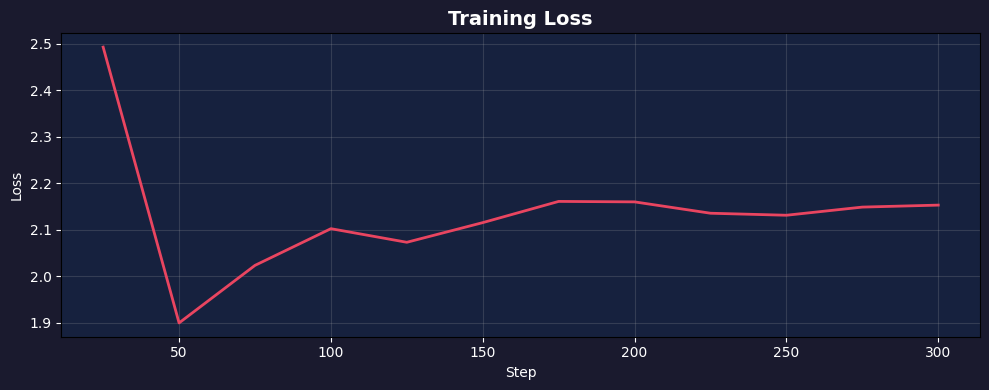

In [25]:
# 6c. Training metrics visualization
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor": "#16213e",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
})

log_history = trainer.state.log_history
train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss  = [x["loss"] for x in log_history if "loss" in x]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(train_steps, train_loss, color="#e94560", linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("/content/MediFirst/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

import gc, torch
gc.collect()
torch.cuda.empty_cache()

## Section 7 — EvaluationCompare fine-tuned model responses against baseline.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [26]:
# 7a. Generate fine-tuned responses
import json
import os
import torch

FT_RESPONSES_PATH = "/content/MediFirst/finetuned_responses.json"

if os.path.exists(FT_RESPONSES_PATH):
    with open(FT_RESPONSES_PATH) as f:
        ft_responses = json.load(f)
    print(f"[SUCCESS] Loaded {len(ft_responses)} cached fine-tuned responses.")
else:
    print("[PROCESS] Generating fine-tuned responses...")
    model.eval()
    model.config.use_cache = True
    ft_responses = []
    with torch.inference_mode():
        for i, pt in enumerate(EVAL_PROMPTS):
            messages = [{"role": "user", "content": pt}]
            prompt = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            inputs = tokenizer(
                prompt, return_tensors="pt", add_special_tokens=False
            ).to(model.device)
            outputs = model.generate(
                **inputs, max_new_tokens=300, do_sample=False, use_cache=True
            )
            response = tokenizer.decode(
                outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
            ).strip()
            ft_responses.append({"prompt": pt, "response": response})
            print(f"   [{i+1}/{len(EVAL_PROMPTS)}] Done")

    with open(FT_RESPONSES_PATH, 'w') as f:
        json.dump(ft_responses, f, indent=2)
    print("[SAVE] Fine-tuned responses saved.")
    model.config.use_cache = False

[PROCESS] Generating fine-tuned responses...
   [1/10] Done
   [2/10] Done
   [3/10] Done
   [4/10] Done
   [5/10] Done
   [6/10] Done
   [7/10] Done
   [8/10] Done
   [9/10] Done
   [10/10] Done
[SAVE] Fine-tuned responses saved.


In [27]:
# 7b. Side-by-side comparison
print("=" * 70)
print("  BASE MODEL  vs  FINE-TUNED MODEL  — Side-by-Side Comparison")
print("=" * 70)

for i in range(len(EVAL_PROMPTS)):
    print(f"\n{'\u2501' * 70}")
    print(f"PROMPT {i+1}: {EVAL_PROMPTS[i]}")
    print(f"{'\u2500' * 70}")
    print("\u25b6 BASE MODEL:")
    print(base_responses[i]["response"][:500])
    print(f"{'\u2500' * 70}")
    print("\u25b6 FINE-TUNED:")
    print(ft_responses[i]["response"][:500])
    print()

  BASE MODEL  vs  FINE-TUNED MODEL  — Side-by-Side Comparison

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROMPT 1: A person has collapsed and is not breathing. They have no pulse. Describe the CPR procedure step by step.
──────────────────────────────────────────────────────────────────────
▶ BASE MODEL:
Okay, this is a critical situation. **Right now, your priority is to call emergency services immediately (911 or your local emergency number) and begin CPR immediately.**  Don't hesitate – every second counts.  Here's a breakdown of the CPR procedure, emphasizing the steps and what you're aiming for. **This is a simplified guide and should not replace formal training.  It's highly recommended that you take a certified CPR course.**

**1. Assess the Situation & Ensure Safety (Seconds)**

* **Chec
──────────────────────────────────────────────────────────────────────
▶ FINE-TUNED:
This is an emergency emergency. Call emergency services immediately.

Note: Thi

---## Section 8 — Save & Export

In [28]:
# 8a. Save LoRA adapter locally
ADAPTER_DIR = "/content/MediFirst/medifirst-lora-adapter"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"[SUCCESS] LoRA adapter saved to {ADAPTER_DIR}")

# List saved files
for f in os.listdir(ADAPTER_DIR):
    size_kb = os.path.getsize(f"{ADAPTER_DIR}/{f}") / 1024
    print(f"   {f}: {size_kb:.1f} KB")

[SUCCESS] LoRA adapter saved to /content/MediFirst/medifirst-lora-adapter
   adapter_config.json: 1.0 KB
   README.md: 5.1 KB
   adapter_model.safetensors: 2938.8 KB
   tokenizer.json: 32602.0 KB
   chat_template.jinja: 1.5 KB
   tokenizer_config.json: 0.7 KB


In [31]:
# 8b. Download adapter (optional)
from google.colab import files
import shutil

# Zip the adapter for easy download
shutil.make_archive("/content/medifirst-lora-adapter", 'zip', ADAPTER_DIR)
files.download("/content/medifirst-lora-adapter.zip")

print("[SUCCESS] Adapter download started.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[SUCCESS] Adapter download started.
